# Singlet Atlas: Corpus Analytics

Distribution of QC metrics across all successfully processed samples in the Singlet Atlas.
**993** successful samples from **2,386** total processed, spanning **7** species and **14** protocols.

In [1]:
import singlet
import pandas as pd
import matplotlib.pyplot as plt

# Load the bundled catalog
singlet.summary()

singlet atlas: 2,386 samples (993 SUCCESS) • 1,178 series • 7 species • 2.9M cells


In [2]:
# QC distributions across all successful samples
df = singlet.sample_index()
success = df[df['status'] == 'SUCCESS']
print(f'Successful samples: {len(success):,} / {len(df):,} total')
print(f'Species: {singlet.species()}')
print(f'Protocols: {success["protocol"].nunique()} unique')

Successful samples: 993 / 2,386 total
Species: ['Danio rerio', 'Drosophila melanogaster', 'Gallus gallus', 'Homo sapiens', 'Macaca mulatta', 'Mus musculus', 'Pan troglodytes']
Protocols: 14 unique


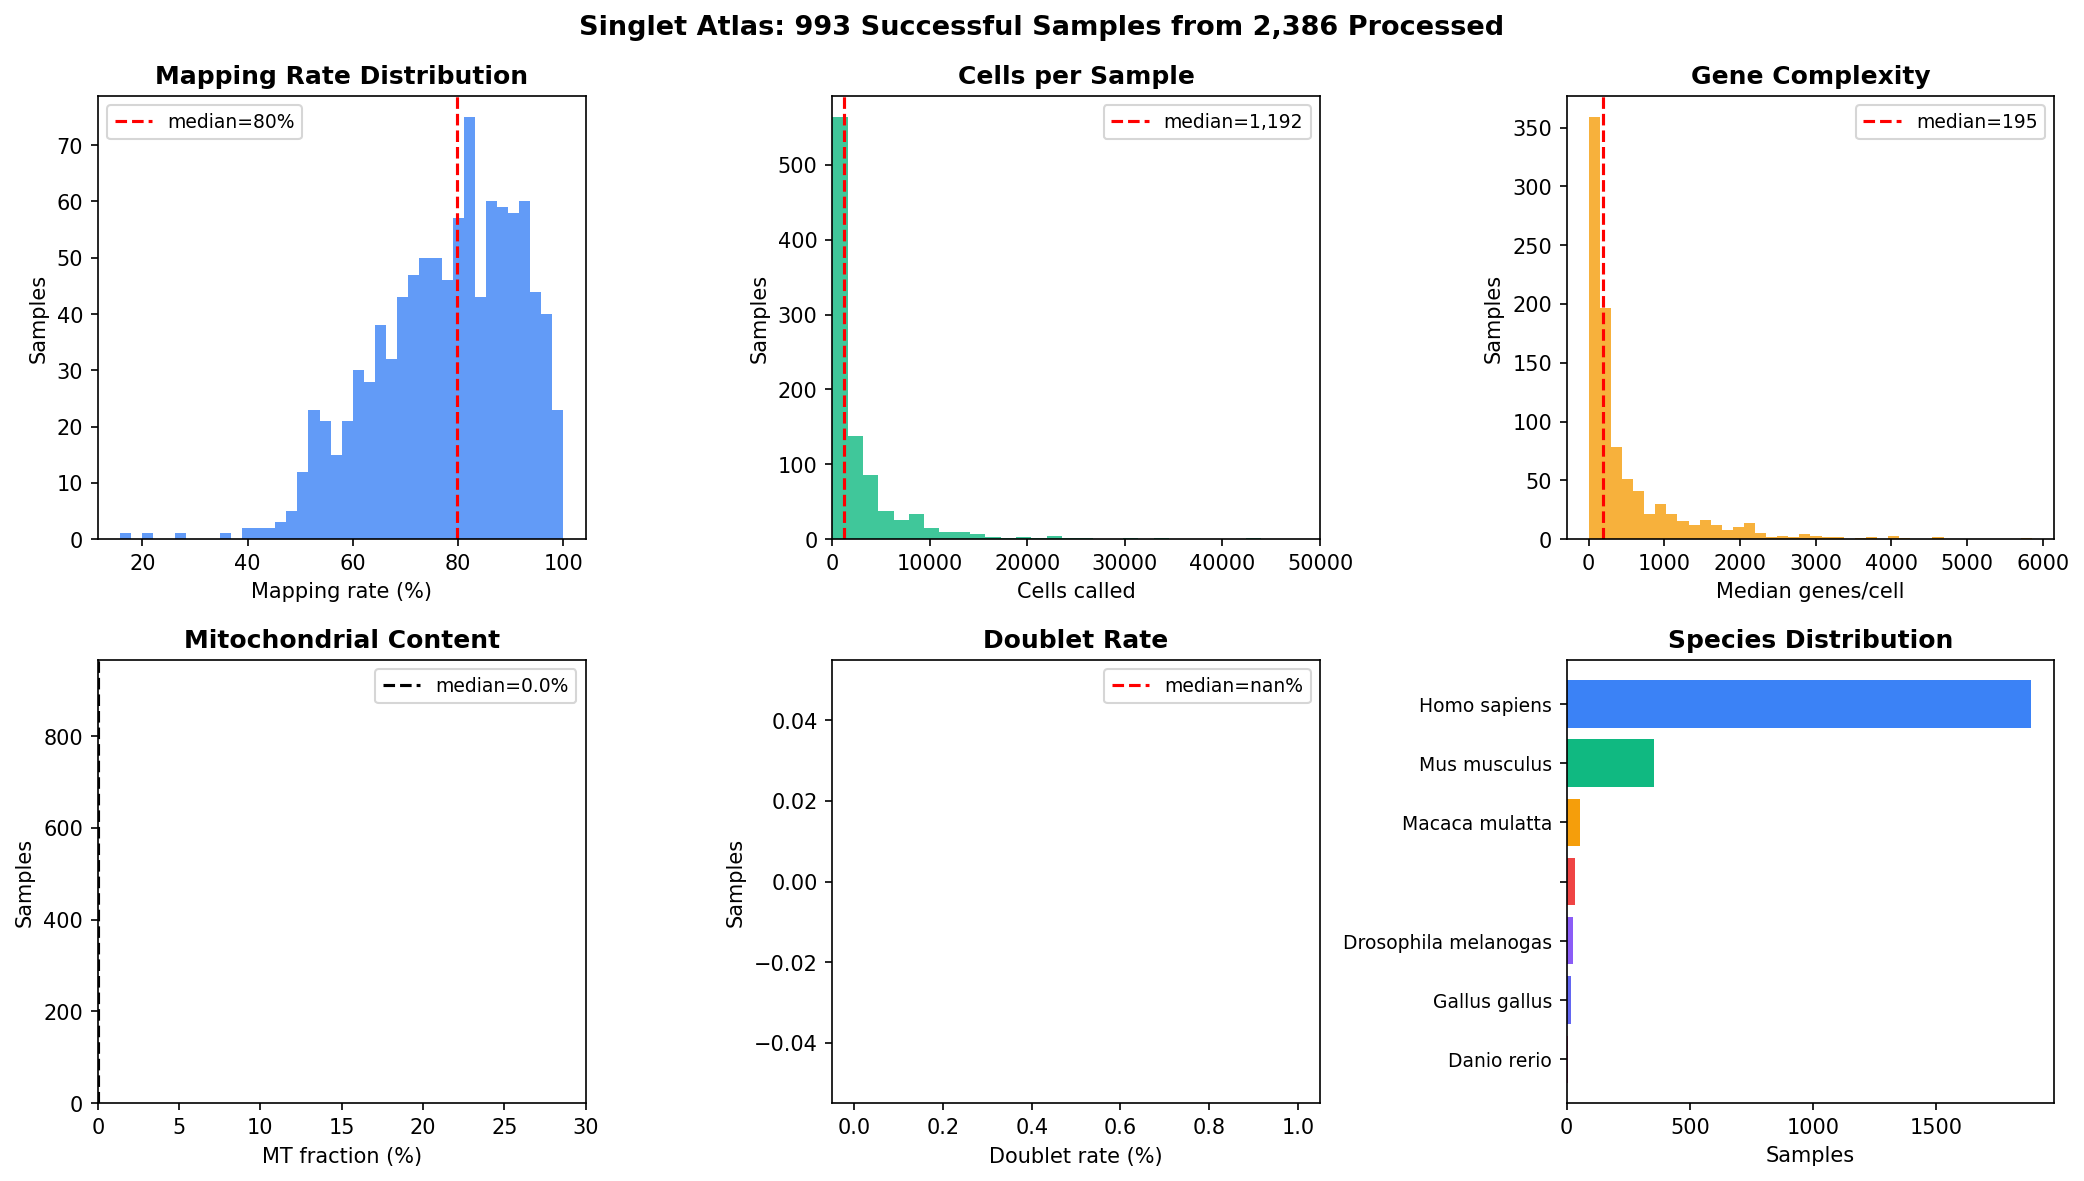

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Mapping rate
ax = axes[0, 0]
vals = success['mapping_rate'].dropna() * 100
ax.hist(vals, bins=40, color='#3b82f6', alpha=0.8, edgecolor='none')
ax.axvline(vals.median(), color='red', linestyle='--', label=f'median={vals.median():.0f}%')
ax.set_xlabel('Mapping rate (%)')
ax.set_title('Mapping Rate', fontweight='bold')
ax.legend(fontsize=9)

# Cells called
ax = axes[0, 1]
vals = success['cells_called'].dropna()
ax.hist(vals, bins=50, color='#10b981', alpha=0.8, edgecolor='none')
ax.axvline(vals.median(), color='red', linestyle='--', label=f'median={vals.median():,.0f}')
ax.set_xlabel('Cells called')
ax.set_title('Cells per Sample', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 50000)

# Median genes/cell
ax = axes[0, 2]
vals = success['median_genes'].dropna()
ax.hist(vals, bins=40, color='#f59e0b', alpha=0.8, edgecolor='none')
ax.axvline(vals.median(), color='red', linestyle='--', label=f'median={vals.median():,.0f}')
ax.set_xlabel('Median genes/cell')
ax.set_title('Gene Complexity', fontweight='bold')
ax.legend(fontsize=9)

# MT %
ax = axes[1, 0]
vals = success['mt_pct'].dropna() * 100
ax.hist(vals, bins=40, color='#ef4444', alpha=0.8, edgecolor='none')
ax.axvline(vals.median(), color='black', linestyle='--', label=f'median={vals.median():.1f}%')
ax.set_xlabel('MT fraction (%)')
ax.set_title('Mitochondrial Content', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 30)

# Doublet rate
ax = axes[1, 1]
vals = success['doublet_rate'].dropna() * 100
ax.hist(vals, bins=40, color='#8b5cf6', alpha=0.8, edgecolor='none')
ax.axvline(vals.median(), color='red', linestyle='--', label=f'median={vals.median():.1f}%')
ax.set_xlabel('Doublet rate (%)')
ax.set_title('Doublet Rate', fontweight='bold')
ax.legend(fontsize=9)

# Species breakdown
ax = axes[1, 2]
species_counts = df['organism'].value_counts().head(7)
ax.barh(range(len(species_counts)), species_counts.values)
ax.set_yticks(range(len(species_counts)))
ax.set_yticklabels(species_counts.index, fontsize=9)
ax.set_xlabel('Samples')
ax.set_title('Species Distribution', fontweight='bold')
ax.invert_yaxis()

plt.suptitle(f'Singlet Atlas: {len(success):,} Successful Samples', fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

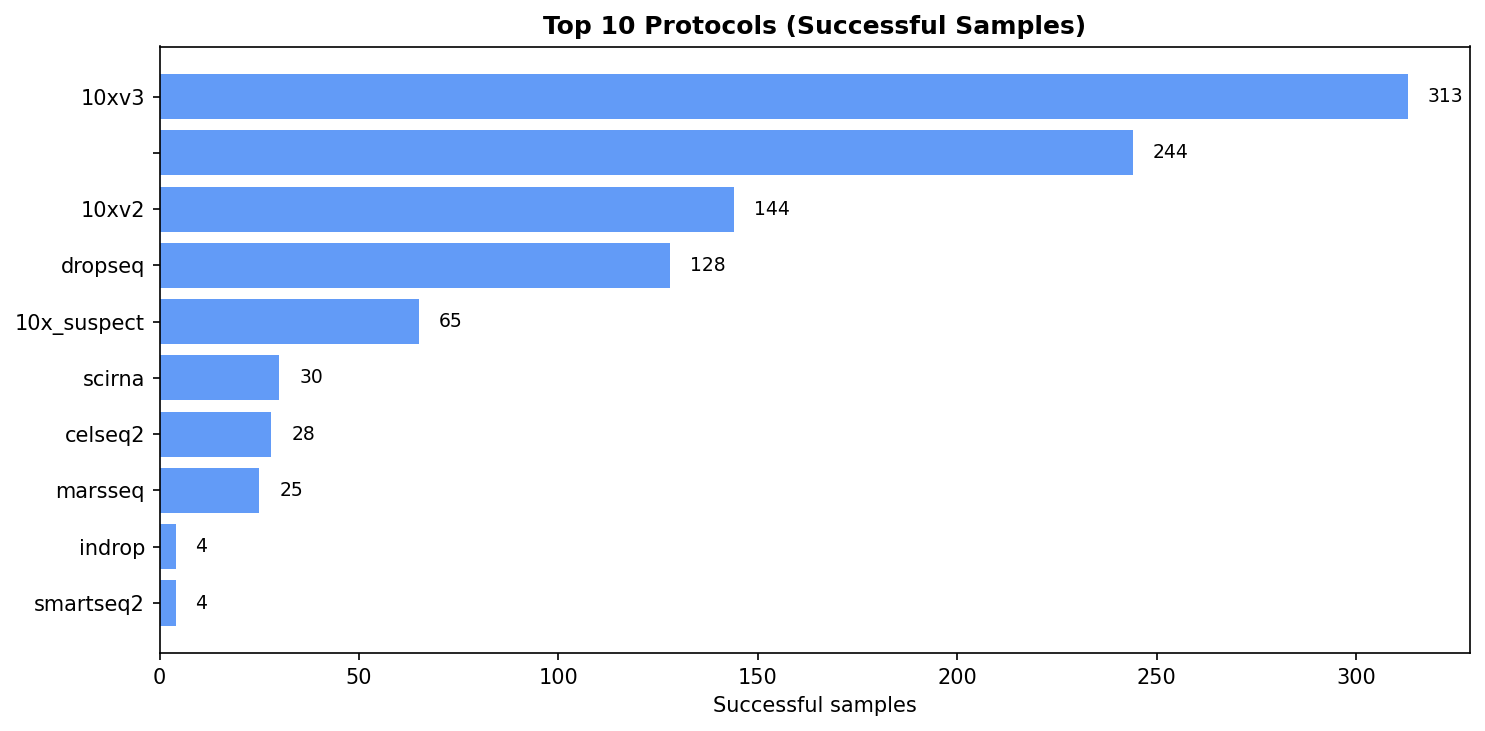

In [4]:
# Protocol breakdown
fig, ax = plt.subplots(figsize=(10, 5))
proto_counts = success['protocol'].value_counts().head(10)
ax.barh(range(len(proto_counts)), proto_counts.values, color='#3b82f6', alpha=0.8)
ax.set_yticks(range(len(proto_counts)))
ax.set_yticklabels(proto_counts.index, fontsize=10)
ax.set_xlabel('Successful samples')
ax.set_title('Top 10 Protocols', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(proto_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# Summary statistics table
stats = pd.DataFrame({
    'Metric': ['Mapping rate', 'Cells/sample', 'Median genes/cell', 'MT %', 'Doublet rate'],
    'Median': [
        f"{success['mapping_rate'].median()*100:.1f}%",
        f"{success['cells_called'].median():,.0f}",
        f"{success['median_genes'].median():,.0f}",
        f"{success['mt_pct'].median()*100:.1f}%",
        f"{success['doublet_rate'].median()*100:.1f}%"
    ],
    'Mean': [
        f"{success['mapping_rate'].mean()*100:.1f}%",
        f"{success['cells_called'].mean():,.0f}",
        f"{success['median_genes'].mean():,.0f}",
        f"{success['mt_pct'].mean()*100:.1f}%",
        f"{success['doublet_rate'].mean()*100:.1f}%"
    ]
})
stats

Metric,Median,Mean
Mapping rate,79.7%,77.8%
Cells/sample,"1,192","3,079"
Median genes/cell,195,505
MT %,0.0%,0.0%
Doublet rate,nan%,nan%


## Key Takeaways

- **993** samples processed successfully out of 2,386 attempted (42% success rate)
- **7 species** covered with human and mouse dominating
- Median **80%** mapping rate across successful samples
- Median **1,192** cells per sample
- 10x Chromium v3 is the dominant protocol

All data is accessible via `pip install singlet-bio` — no downloads required.